# Trabajo Final — Probabilidad y Estadística para la IA

**Especialización en Inteligencia Artificial — Laboratorio de Sistemas Embebidos, UBA**

Los cinco supermercados de Don Francisco ('Santa Ana', 'La Floresta', 'Los Cedros',
'Palermo' y 'Córdoba') motivan dos preguntas de investigación:

1. **¿Cómo se comporta la afluencia mensual de clientes de 'Santa Ana'?**
   Se responde con intervalos de confianza empíricos por mes (Punto 2).
2. **¿Es la afluencia igual en todas las tiendas, o alguna necesita más atención?**
   Se responde con un ANOVA de un factor (Punto 3) y un contraste dirigido entre
   la mejor y la peor tienda (Punto 4).

---

## Punto 1: Simulación de clientes diarios

Se simula el número de clientes diarios $Y_{t,s}$ para cada fecha $t$ y tienda $s$,
entre el 2023-01-01 y el 2025-12-31, mediante

$$Y_{t,s} \sim \text{Poisson}(\lambda_{t,s})$$

donde el parámetro es **aditivo** en los cuatro efectos:

$$\lambda_{t,s} = \alpha_{\text{año}(t)} + \beta_{\text{mes}(t)} + \gamma_{\text{díasem}(t)} + \delta_{s}$$

- $\alpha$: efecto anual (1000 / 1500 / 2000)
- $\beta$: efecto mensual (1000 … 3000)
- $\gamma$: efecto día de la semana (1000 … 3500)
- $\delta$: efecto por tienda (1000 … 5000)

No hay término de error aditivo: **toda** la aleatoriedad proviene del muestreo Poisson.
Por lo tanto $E[Y_{t,s}] = \lambda_{t,s}$ y $\text{Var}(Y_{t,s} \mid \lambda_{t,s}) = \lambda_{t,s}$,
es decir un desvío **condicional** de $\sqrt{\lambda} \approx 100$ para $\lambda \approx 10000$.

> **Nota sobre las dos varianzas.** El desvío marginal de una tienda a lo largo de los
> 1096 días es mucho mayor (~1180), porque a la variabilidad Poisson se le suma la
> variación determinística de $\lambda$ entre años, meses y días de semana. Por la ley
> de varianza total:
> $$\text{Var}(Y) = \underbrace{E[\text{Var}(Y\mid\lambda)]}_{=E[\lambda]\approx 8700} + \underbrace{\text{Var}(E[Y\mid\lambda])}_{=\text{Var}(\lambda)\approx 1.3\times10^6}$$
> El segundo término domina. Esta distinción es clave para interpretar los Puntos 2 y 3.

In [21]:
import numpy as np
import pandas as pd

SEED = 42
DATA = "./data"

# Cada tabla trae su columna "effect"; la renombramos para poder mergear las
# cuatro sin colisiones de nombres.
store_effect = pd.read_csv(f"{DATA}/store.csv").rename(columns={"effect": "eff_store"})
year_effect = pd.read_csv(f"{DATA}/year.csv").rename(columns={"effect": "eff_year"})
month_effect = pd.read_csv(f"{DATA}/month.csv").rename(columns={"effect": "eff_month"})
day_effect = pd.read_csv(f"{DATA}/day.csv").rename(columns={"effect": "eff_day"})

display(store_effect, year_effect, month_effect, day_effect)

,store,eff_store
0,Santa Ana,5000
1,La Floresta,2000
2,Los Cedros,3000
3,Palermo,1000
4,Córdoba,3000


,year,eff_year
0,2023,1000
1,2024,1500
2,2025,2000


,month_num,month,eff_month
0,1,Enero,1000
1,2,Febrero,1500
2,3,Marzo,2000
3,4,Abril,2000
4,5,Mayo,2500
5,6,Junio,2500
6,7,Julio,3000
7,8,Agosto,2500
8,9,Septiembre,2500
9,10,Octubre,2000


,day_num,day,eff_day
0,6,Domingo,1000
1,0,Lunes,2000
2,1,Martes,3000
3,2,Miércoles,3500
4,3,Jueves,3000
5,4,Viernes,2000
6,5,Sábado,1000


### 1.1 Grilla fecha × tienda

El producto cartesiano real es **fechas × tiendas** (1096 días × 5 tiendas = 5480 filas).
Los efectos de año, mes y día de semana no son productos cartesianos sino *lookups*:
se incorporan con merges por clave sobre columnas derivadas de la fecha.

Convención de `pandas`: `dt.weekday` devuelve **Lunes = 0 … Domingo = 6**, y `day.csv`
ya trae la columna `day_num` con esa misma codificación.

In [22]:
fechas = pd.DataFrame({"date": pd.date_range("2023-01-01", "2025-12-31", freq="D")})

# Producto cartesiano fechas x tiendas
df = fechas.merge(store_effect, how="cross")

# Claves derivadas de la fecha para los lookups de efectos
df["year"] = df["date"].dt.year
df["month_num"] = df["date"].dt.month  # 1..12
df["day_num"] = df["date"].dt.weekday  # Lunes=0 ... Domingo=6

# Lookups de los tres efectos temporales
df = (
    df.merge(year_effect, on="year", how="left")
    .merge(month_effect, on="month_num", how="left")
    .merge(day_effect, on="day_num", how="left")
)

df = df.sort_values(["date", "store"]).reset_index(drop=True)
print(df.shape)
df.head()

(5480, 11)


,date,store,eff_store,year,month_num,day_num,eff_year,month,eff_month,day,eff_day
0,2023-01-01,Córdoba,3000,2023,1,6,1000,Enero,1000,Domingo,1000
1,2023-01-01,La Floresta,2000,2023,1,6,1000,Enero,1000,Domingo,1000
2,2023-01-01,Los Cedros,3000,2023,1,6,1000,Enero,1000,Domingo,1000
3,2023-01-01,Palermo,1000,2023,1,6,1000,Enero,1000,Domingo,1000
4,2023-01-01,Santa Ana,5000,2023,1,6,1000,Enero,1000,Domingo,1000


### 1.2 Cálculo de $\lambda_{t,s}$ y muestreo Poisson

$$\lambda_{t,s} = \text{eff\_year} + \text{eff\_month} + \text{eff\_day} + \text{eff\_store}$$

Se fija la semilla del generador para que la simulación sea reproducible y los números
del informe no cambien entre corridas. `rng.poisson` acepta un vector de $\lambda$ y
devuelve una realización independiente por elemento.

In [23]:
EFECTOS = ["eff_year", "eff_month", "eff_day", "eff_store"]
df["lambda"] = df[EFECTOS].sum(axis=1)

rng = np.random.default_rng(SEED)
df["clients"] = rng.poisson(df["lambda"])

cols = ["date", "year", "month", "day", "store", *EFECTOS, "lambda", "clients"]
df = df[cols]
df.head(10)

,date,year,month,day,store,eff_year,eff_month,eff_day,eff_store,lambda,clients
0,2023-01-01,2023,Enero,Domingo,Córdoba,1000,1000,1000,3000,6000,6066
1,2023-01-01,2023,Enero,Domingo,La Floresta,1000,1000,1000,2000,5000,5087
2,2023-01-01,2023,Enero,Domingo,Los Cedros,1000,1000,1000,3000,6000,5878
3,2023-01-01,2023,Enero,Domingo,Palermo,1000,1000,1000,1000,4000,4051
4,2023-01-01,2023,Enero,Domingo,Santa Ana,1000,1000,1000,5000,8000,7883
5,2023-01-02,2023,Enero,Lunes,Córdoba,1000,1000,2000,3000,7000,6969
6,2023-01-02,2023,Enero,Lunes,La Floresta,1000,1000,2000,2000,6000,6032
7,2023-01-02,2023,Enero,Lunes,Los Cedros,1000,1000,2000,3000,7000,6987
8,2023-01-02,2023,Enero,Lunes,Palermo,1000,1000,2000,1000,5000,5011
9,2023-01-02,2023,Enero,Lunes,Santa Ana,1000,1000,2000,5000,9000,9101


### 1.3 Chequeos de sanidad

Antes de usar los datos se verifica que la construcción sea correcta:

- **Dimensión**: 1096 días × 5 tiendas = 5480 filas.
- **Sin nulos**: un `NaN` delataría un merge fallido por clave mal mapeada.
- **Rango de $\lambda$**: el mínimo teórico es $1000+1000+1000+1000 = 4000$
  (Palermo, un domingo de enero o diciembre de 2023) y el máximo
  $2000+3000+3500+5000 = 13500$ (Santa Ana, un miércoles de julio de 2025).
- **Orden de las medias por tienda**: debe replicar el orden de los efectos de tienda.

In [24]:
assert len(df) == 1096 * 5, f"Se esperaban 5480 filas, hay {len(df)}"
assert df.isna().sum().sum() == 0, "Hay nulos: algún merge falló"
assert df["lambda"].min() == 4000, df["lambda"].min()
assert df["lambda"].max() == 13500, df["lambda"].max()
print("Chequeos OK")

resumen = (
    df.groupby("store")
    .agg(eff_store=("eff_store", "first"),
         lambda_medio=("lambda", "mean"),
         clientes_medio=("clients", "mean"),
         desvio=("clients", "std"))
    .sort_values("clientes_medio", ascending=False)
)
resumen

Chequeos OK


,eff_store,lambda_medio,clientes_medio,desvio
store,,,,
Santa Ana,5000,10717.153285,10711.312956,1186.901644
Córdoba,3000,8717.153285,8715.491788,1179.203811
Los Cedros,3000,8717.153285,8715.037409,1180.498083
La Floresta,2000,7717.153285,7720.047445,1179.452993
Palermo,1000,6717.153285,6716.045620,1185.449863


In [25]:
df.to_csv(f"{DATA}/consolidated.csv", index=False)
print(f"Guardado: {DATA}/consolidated.csv  ({len(df)} filas)")

Guardado: ./data/consolidated.csv  (5480 filas)


---

## Punto 2: Intervalos de confianza empíricos para 'Santa Ana' por mes

**Problema.** Don Francisco quiere entender la afluencia mensual de 'Santa Ana'. Para cada
uno de los 12 meses calendario se construye un intervalo que capture el rango típico de
clientes diarios, a niveles de confianza del 95 % y del 99 %.

### Qué se entiende por "intervalo de confianza empírico"

El enunciado pide intervalos **empíricos**, es decir construidos a partir de los cuantiles
observados de los datos y no de una fórmula paramétrica. Para un mes $m$ con muestra
$\{y_1,\dots,y_{n_m}\}$ de clientes diarios, el intervalo empírico de nivel $1-\alpha$ es

$$\left[\hat{q}_{\alpha/2},\; \hat{q}_{1-\alpha/2}\right]$$

donde $\hat{q}_p$ es el cuantil muestral de orden $p$. Con $\alpha = 0.05$ se usan los
percentiles 2.5 y 97.5; con $\alpha = 0.01$, los percentiles 0.5 y 99.5.

> **Atención — dos objetos distintos que suelen confundirse.**
>
> 1. **Intervalo de predicción / de dispersión** (§ 2.1): cubre el 95 % de los *días
>    individuales* del mes. Su ancho refleja la variabilidad real de la demanda diaria y
>    **no** se achica al agregar años de datos.
> 2. **Intervalo de confianza para la media** $\mu_m$ (§ 2.2): cubre el parámetro
>    poblacional y se achica como $1/\sqrt{n}$.
>
> Para la pregunta de negocio —"¿cuántos clientes espero un día cualquiera de julio?"— el
> objeto útil es el primero. Se reportan **ambos**: el de dispersión por cuantiles
> muestrales, y el de la media mediante el estadístico $z$.

### Fuente de variabilidad dentro de un mes

Cada mes agrupa ~93 días (31 días × 3 años, según el mes) y esos días **no** son homogéneos:
$\lambda$ varía por el año (1000/1500/2000) y por el día de la semana (1000…3500). El
intervalo empírico mensual es por lo tanto **multimodal** — mezcla domingos flojos de 2023
con miércoles fuertes de 2025. Es el comportamiento correcto para la pregunta planteada,
pero conviene tenerlo presente al leer los anchos.

### 2.1 Intervalos empíricos de dispersión (cuantiles muestrales)

In [26]:
MESES = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

santa_ana = df[df["store"] == "Santa Ana"].copy()
santa_ana["month"] = pd.Categorical(santa_ana["month"], categories=MESES, ordered=True)

# Intervalos empiricos de dispersion: cuantiles muestrales directos.
ic_dispersion = (
    santa_ana.groupby("month", observed=True)["clients"]
    .agg(n="size",
         media="mean",
         desvio="std",
         p0_5=lambda s: s.quantile(0.005),
         p2_5=lambda s: s.quantile(0.025),
         p97_5=lambda s: s.quantile(0.975),
         p99_5=lambda s: s.quantile(0.995))
    .reset_index()
)

ic_dispersion["IC95"] = ic_dispersion.apply(
    lambda r: f"[{r.p2_5:,.0f} ; {r.p97_5:,.0f}]", axis=1)
ic_dispersion["IC99"] = ic_dispersion.apply(
    lambda r: f"[{r.p0_5:,.0f} ; {r.p99_5:,.0f}]", axis=1)
ic_dispersion["ancho95"] = ic_dispersion["p97_5"] - ic_dispersion["p2_5"]
ic_dispersion["ancho99"] = ic_dispersion["p99_5"] - ic_dispersion["p0_5"]

ic_dispersion[["month", "n", "media", "desvio", "IC95", "ancho95", "IC99", "ancho99"]]

,month,n,media,desvio,IC95,ancho95,IC99,ancho99
0,Enero,93,9751.784946,1040.250418,"[7,986 ; 11,556]",3569.700,"[7,846 ; 11,607]",3760.860
1,Febrero,85,10221.764706,1021.310021,"[8,411 ; 12,066]",3655.100,"[8,335 ; 12,202]",3867.740
2,Marzo,93,10655.870968,1003.449932,"[8,935 ; 12,464]",3529.400,"[8,872 ; 12,614]",3742.340
3,Abril,90,10716.055556,1046.435945,"[8,977 ; 12,492]",3515.325,"[8,794 ; 12,543]",3749.725
4,Mayo,93,11255.290323,1014.606473,"[9,403 ; 12,907]",3504.200,"[9,293 ; 13,018]",3725.100
5,Junio,90,11162.055556,1011.255237,"[9,481 ; 13,003]",3522.475,"[9,406 ; 13,104]",3697.480
6,Julio,93,11724.784946,1055.178038,"[9,958 ; 13,458]",3499.500,"[9,910 ; 13,597]",3686.800
7,Agosto,93,11209.139785,986.272336,"[9,448 ; 12,980]",3532.200,"[9,372 ; 13,059]",3686.840
8,Septiembre,90,11185.455556,1027.475527,"[9,444 ; 12,888]",3443.375,"[9,406 ; 13,090]",3684.200
9,Octubre,93,10737.978495,1023.248992,"[8,970 ; 12,462]",3491.900,"[8,818 ; 12,579]",3760.740


### 2.2 Intervalo de confianza para la media mensual (estadístico z)

Para el segundo objeto —el IC de la **media** $\mu_m$— se usa el estadístico $z$:

$$\text{IC}_{1-\alpha}(\mu_m) = \bar{y}_m \pm z_{1-\alpha/2}\,\frac{s_m}{\sqrt{n_m}}$$

con $z_{0.975} = 1.96$ para el 95 % y $z_{0.995} = 2.576$ para el 99 %.

**Justificación del uso de $z$ y no de $t$.** Con $n_m \approx 90$ días por mes, el Teorema
Central del Límite garantiza que $\bar{y}_m$ es aproximadamente normal aunque los datos
individuales sean multimodales, y $s_m$ estima $\sigma_m$ con precisión suficiente para
tratarla como conocida. La diferencia entre $t_{89;\,0.975} = 1.987$ y $z_{0.975} = 1.960$
es inferior al 1.4 %, despreciable frente a la magnitud de los intervalos.

In [27]:
from scipy import stats

Z95 = stats.norm.ppf(0.975)   # 1.959964
Z99 = stats.norm.ppf(0.995)   # 2.575829

filas = []
for mes in MESES:
    y = santa_ana.loc[santa_ana["month"] == mes, "clients"].to_numpy()
    n = y.size
    media, s = y.mean(), y.std(ddof=1)
    ee = s / np.sqrt(n)

    filas.append({
        "month": mes, "n": n, "media": media, "desvio": s, "error_estandar": ee,
        "IC95_media": f"[{media - Z95*ee:,.1f} ; {media + Z95*ee:,.1f}]",
        "IC99_media": f"[{media - Z99*ee:,.1f} ; {media + Z99*ee:,.1f}]",
        "ancho95": 2 * Z95 * ee,
    })

ic_media = pd.DataFrame(filas)
display(ic_media)

print(f"z_0.975 = {Z95:.6f}     z_0.995 = {Z99:.6f}")
print("\nAncho medio del IC de la MEDIA (95%)      : "
      f"{ic_media['ancho95'].mean():,.1f} clientes")
print("Ancho medio del IC de DISPERSION (95%)    : "
      f"{ic_dispersion['ancho95'].mean():,.1f} clientes")
print(f"Razon entre ambos: {ic_dispersion['ancho95'].mean() / ic_media['ancho95'].mean():.1f}x")

,month,n,media,desvio,error_estandar,IC95_media,IC99_media,ancho95
0,Enero,93,9751.784946,1040.250418,107.868943,"[9,540.4 ; 9,963.2]","[9,473.9 ; 10,029.6]",422.838488
1,Febrero,85,10221.764706,1021.310021,110.776625,"[10,004.6 ; 10,438.9]","[9,936.4 ; 10,507.1]",434.236391
2,Marzo,93,10655.870968,1003.449932,104.052911,"[10,451.9 ; 10,859.8]","[10,387.8 ; 10,923.9]",407.879915
3,Abril,90,10716.055556,1046.435945,110.304034,"[10,499.9 ; 10,932.2]","[10,431.9 ; 11,000.2]",432.383867
4,Mayo,93,11255.290323,1014.606473,105.209790,"[11,049.1 ; 11,461.5]","[10,984.3 ; 11,526.3]",412.414799
5,Junio,90,11162.055556,1011.255237,106.595661,"[10,953.1 ; 11,371.0]","[10,887.5 ; 11,436.6]",417.847315
6,Julio,93,11724.784946,1055.178038,109.416865,"[11,510.3 ; 11,939.2]","[11,442.9 ; 12,006.6]",428.906231
7,Agosto,93,11209.139785,986.272336,102.271677,"[11,008.7 ; 11,409.6]","[10,945.7 ; 11,472.6]",400.897607
8,Septiembre,90,11185.455556,1027.475527,108.305430,"[10,973.2 ; 11,397.7]","[10,906.5 ; 11,464.4]",424.549485
9,Octubre,93,10737.978495,1023.248992,106.105978,"[10,530.0 ; 10,945.9]","[10,464.7 ; 11,011.3]",415.927789


z_0.975 = 1.959964     z_0.995 = 2.575829

Ancho medio del IC de la MEDIA (95%)      : 419.0 clientes
Ancho medio del IC de DISPERSION (95%)    : 3,524.3 clientes
Razon entre ambos: 8.4x


### 2.3 Visualización

Se grafican las bandas empíricas de dispersión por mes. La forma es de **énfasis**:
una sola serie ('Santa Ana'), con las dos bandas anidadas en una rampa secuencial de un
único tono —más claro = intervalo más ancho— y el resto del gráfico en grises recesivos.
La banda del 99 % contiene por construcción a la del 95 %.

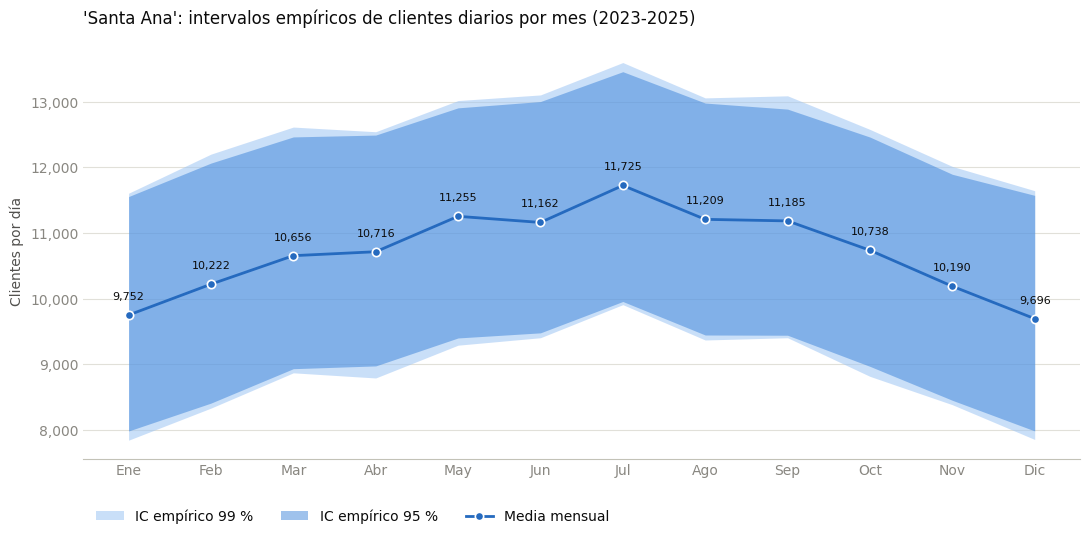

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Paleta: rampa secuencial de un tono + grises recesivos
AZUL_500, AZUL_450, AZUL_200 = "#256abf", "#2a78d6", "#9ec5f4"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

x = np.arange(12)
d = ic_dispersion

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.fill_between(x, d["p0_5"], d["p99_5"], color=AZUL_200, alpha=0.55,
                linewidth=0, label="IC empírico 99 %", zorder=2)
ax.fill_between(x, d["p2_5"], d["p97_5"], color=AZUL_450, alpha=0.45,
                linewidth=0, label="IC empírico 95 %", zorder=3)
ax.plot(x, d["media"], color=AZUL_500, linewidth=2, marker="o",
        markersize=6, markeredgecolor="white", markeredgewidth=1.2,
        label="Media mensual", zorder=4)

# Etiquetas directas sobre la media (relief para las bandas de bajo contraste)
for xi, mi in zip(x, d["media"]):
    ax.annotate(f"{mi:,.0f}", (xi, mi), textcoords="offset points",
                xytext=(0, 11), ha="center", fontsize=8, color=INK)

ax.set_xticks(x)
ax.set_xticklabels([m[:3] for m in d["month"]], color=MUTED)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.tick_params(colors=MUTED, length=0)
ax.set_ylabel("Clientes por día", color="#52514e")
ax.set_title("'Santa Ana': intervalos empíricos de clientes diarios por mes (2023-2025)",
             color=INK, fontsize=12, pad=14, loc="left")

ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.legend(frameon=False, ncols=3, loc="upper left",
          bbox_to_anchor=(0, -0.09), labelcolor=INK)

fig.tight_layout()
plt.show()

---

## Punto 3: ANOVA de un factor entre las cinco tiendas

**Problema.** ¿Es el número esperado de clientes igual en las cinco tiendas, o hay
alguna que se comporte mejor o peor que las demás?

### Hipótesis

$$H_0:\; \mu_{\text{SA}} = \mu_{\text{LF}} = \mu_{\text{LC}} = \mu_{\text{P}} = \mu_{\text{C}}
\qquad\text{vs.}\qquad
H_1:\; \exists\, i \neq j \;:\; \mu_i \neq \mu_j$$

con nivel de significancia $\alpha = 0.05$.

### Estadístico

Con $k = 5$ grupos y $n = 1096$ observaciones por grupo ($N = 5480$):

$$\text{SC}_{\text{entre}} = \sum_{i=1}^{k} n_i (\bar{y}_i - \bar{y})^2
\qquad
\text{SC}_{\text{dentro}} = \sum_{i=1}^{k}\sum_{j=1}^{n_i} (y_{ij} - \bar{y}_i)^2$$

$$F = \frac{\text{SC}_{\text{entre}} / (k-1)}{\text{SC}_{\text{dentro}} / (N-k)}
    = \frac{\text{CM}_{\text{entre}}}{\text{CM}_{\text{dentro}}}
\;\sim\; F_{k-1,\;N-k} \;\text{ bajo } H_0$$

Se rechaza $H_0$ si $F > F_{0.95;\,4,\,5475}$, equivalentemente si $p < 0.05$.

### Supuestos y su verificación

| Supuesto | Estado en estos datos |
|---|---|
| **Independencia** | Se cumple por construcción: cada $Y_{t,s}$ se muestrea de forma independiente. |
| **Homocedasticidad** | Se verifica con el test de **Bartlett**, cuyo estadístico se distribuye $\chi^2_{k-1}$ bajo $H_0$ de varianzas iguales. Es plausible: aunque $\text{Var}(Y\mid\lambda)=\lambda$ difiere entre tiendas, la varianza marginal está dominada por $\text{Var}(\lambda)$, idéntica en las cinco (los efectos temporales son comunes). |
| **Normalidad** | Los datos son multimodales, **no** normales. Con $n_i = 1096$ el TCL vuelve robusto al test sobre las medias de grupo. Se verifica adicionalmente con una prueba $\chi^2$ de bondad de ajuste. |

**Test de Bartlett** (estadístico $\chi^2$), con $s_p^2$ la varianza combinada:

$$\chi^2 = \frac{(N-k)\ln s_p^2 - \sum_{i=1}^{k}(n_i-1)\ln s_i^2}
{1 + \dfrac{1}{3(k-1)}\left(\sum_{i=1}^{k}\dfrac{1}{n_i-1} - \dfrac{1}{N-k}\right)}
\;\sim\; \chi^2_{k-1}$$

> **Advertencia de interpretación.** Este ANOVA de un factor ignora los efectos de año,
> mes y día, que van íntegros al residuo e inflan $\text{CM}_{\text{dentro}}$. Es por lo
> tanto un test **conservador**: pierde potencia pero no genera falsos positivos. Se
> reporta además un ANOVA de dos factores (tienda + fecha) que aísla el efecto de tienda
> del ruido temporal, y la comparación entre ambos es en sí misma informativa.

In [29]:
TIENDAS = ["Santa Ana", "La Floresta", "Los Cedros", "Palermo", "Córdoba"]
grupos = [df.loc[df["store"] == t, "clients"].to_numpy() for t in TIENDAS]

k, N = len(grupos), sum(g.size for g in grupos)
gl_entre, gl_dentro = k - 1, N - k

# --- Supuesto de homocedasticidad: test de Bartlett (estadistico chi-cuadrado) ---
bart_stat, bart_p = stats.bartlett(*grupos)
chi2_crit_bart = stats.chi2.ppf(0.95, k - 1)
print(f"Bartlett: chi2 = {bart_stat:.4f}   gl = {k-1}   "
      f"chi2_critico(95%) = {chi2_crit_bart:.4f}   p = {bart_p:.4f}")
print("  -> " + ("No se rechaza H0: varianzas homogeneas" if bart_p > 0.05
                 else "Se rechaza H0: varianzas heterogeneas"))

# --- ANOVA de un factor ---
F, p = stats.f_oneway(*grupos)

media_global = np.concatenate(grupos).mean()
sc_entre = sum(g.size * (g.mean() - media_global) ** 2 for g in grupos)
sc_dentro = sum(((g - g.mean()) ** 2).sum() for g in grupos)
cm_entre, cm_dentro = sc_entre / gl_entre, sc_dentro / gl_dentro
f_critico = stats.f.ppf(0.95, gl_entre, gl_dentro)
eta2 = sc_entre / (sc_entre + sc_dentro)

tabla_anova = pd.DataFrame({
    "Fuente": ["Entre tiendas", "Dentro (residuo)", "Total"],
    "SC": [sc_entre, sc_dentro, sc_entre + sc_dentro],
    "gl": [gl_entre, gl_dentro, N - 1],
    "CM": [cm_entre, cm_dentro, np.nan],
    "F": [F, np.nan, np.nan],
    "p-valor": [p, np.nan, np.nan],
})
display(tabla_anova)

print(f"\nF observado   = {F:,.4f}")
print(f"F critico 95% = {f_critico:.4f}   (gl = {gl_entre}, {gl_dentro})")
print(f"p-valor       = {p:.3e}")
print(f"eta^2         = {eta2:.4f}  (proporcion de varianza explicada por la tienda)")
print("\nDecision: " + ("SE RECHAZA H0 -> las medias NO son todas iguales"
                        if p < 0.05 else "No se rechaza H0"))

ValueError: cannot convert float NaN to integer

### 3.2 ANOVA de dos factores y comparaciones múltiples

El ANOVA de un factor manda toda la variación temporal al residuo. Bloqueando por fecha
—es decir, tratando la fecha como segundo factor— el residuo pasa a contener **sólo** el
ruido Poisson, y el contraste entre tiendas gana enormemente en potencia:

$$Y_{ts} = \mu + \tau_s + \beta_t + \varepsilon_{ts}$$

Como todas las tiendas comparten exactamente las mismas 1096 fechas, el diseño está
perfectamente balanceado y ambos factores son ortogonales.

### Comparaciones de a pares mediante $z$ con corrección de Bonferroni

Rechazar $H_0$ sólo dice que *alguna* tienda difiere, no cuál. Para identificar los pares
se aplica el estadístico $z$ a cada una de las $\binom{5}{2} = 10$ comparaciones:

$$z_{ij} = \frac{\bar{y}_i - \bar{y}_j}{\sqrt{\dfrac{s_i^2}{n_i} + \dfrac{s_j^2}{n_j}}}$$

Con 10 contrastes simultáneos a $\alpha = 0.05$ cada uno, la probabilidad de al menos un
falso positivo sube a $1 - 0.95^{10} \approx 40\,\%$. La corrección de **Bonferroni**
restablece el control del error familiar exigiendo

$$p_{ij} < \frac{\alpha}{m} = \frac{0.05}{10} = 0.005
\qquad\Longleftrightarrow\qquad
|z_{ij}| > z_{1 - \alpha/(2m)} = z_{0.9975} = 2.807$$

In [ ]:
# --- ANOVA de dos factores: tienda + fecha (bloque), sin interaccion ---
# Descomposicion directa aprovechando el diseno balanceado.
tabla = df.pivot(index="date", columns="store", values="clients")[TIENDAS]
Y = tabla.to_numpy(dtype=float)
n_fechas, n_tiendas = Y.shape

gran_media = Y.mean()
media_tienda = Y.mean(axis=0)
media_fecha = Y.mean(axis=1)

sc_tienda = n_fechas * ((media_tienda - gran_media) ** 2).sum()
sc_fecha = n_tiendas * ((media_fecha - gran_media) ** 2).sum()
sc_total = ((Y - gran_media) ** 2).sum()
sc_resid = sc_total - sc_tienda - sc_fecha

gl_tienda = n_tiendas - 1
gl_fecha = n_fechas - 1
gl_resid = gl_tienda * gl_fecha

cm_tienda_2f = sc_tienda / gl_tienda
cm_resid_2f = sc_resid / gl_resid
F_tienda_2f = cm_tienda_2f / cm_resid_2f
p_tienda_2f = stats.f.sf(F_tienda_2f, gl_tienda, gl_resid)

F_fecha_2f = (sc_fecha / gl_fecha) / cm_resid_2f
p_fecha_2f = stats.f.sf(F_fecha_2f, gl_fecha, gl_resid)

anova2 = pd.DataFrame({
    "Fuente": ["Tienda", "Fecha (bloque)", "Residuo", "Total"],
    "SC": [sc_tienda, sc_fecha, sc_resid, sc_total],
    "gl": [gl_tienda, gl_fecha, gl_resid, Y.size - 1],
    "CM": [cm_tienda_2f, sc_fecha / gl_fecha, cm_resid_2f, np.nan],
    "F": [F_tienda_2f, F_fecha_2f, np.nan, np.nan],
    "p-valor": [p_tienda_2f, p_fecha_2f, np.nan, np.nan],
})
display(anova2)

print(f"CM residuo 1 factor  = {cm_dentro:,.1f}")
print(f"CM residuo 2 factores= {cm_resid_2f:,.1f}   "
      f"(~ el lambda medio {df['lambda'].mean():,.0f}, como predice Poisson)")
print(f"F(tienda) 1 factor   = {F:,.1f}")
print(f"F(tienda) 2 factores = {F_tienda_2f:,.1f}")

In [ ]:
# --- Comparaciones de a pares con estadistico z + correccion de Bonferroni ---
m = k * (k - 1) // 2                      # 10 comparaciones
alpha_bonf = 0.05 / m                     # 0.005
z_crit_bonf = stats.norm.ppf(1 - alpha_bonf / 2)
efectos_serie = store_effect.set_index("store")["eff_store"]

pares = []
for i in range(k):
    for j in range(i + 1, k):
        yi, yj = grupos[i], grupos[j]
        d_ij = yi.mean() - yj.mean()
        ee_ij = np.sqrt(yi.var(ddof=1) / yi.size + yj.var(ddof=1) / yj.size)
        z_ij = d_ij / ee_ij
        p_ij = 2 * stats.norm.sf(abs(z_ij))
        pares.append({
            "Tienda A": TIENDAS[i], "Tienda B": TIENDAS[j],
            "dif. medias": d_ij,
            "dif. efectos": efectos_serie[TIENDAS[i]] - efectos_serie[TIENDAS[j]],
            "z": z_ij,
            "IC95 inf": d_ij - z_crit_bonf * ee_ij,
            "IC95 sup": d_ij + z_crit_bonf * ee_ij,
            "p-valor": p_ij,
            "p Bonferroni": min(p_ij * m, 1.0),
        })

pares_df = pd.DataFrame(pares)
pares_df["significativo"] = np.where(pares_df["p-valor"] < alpha_bonf, "Sí", "No")
display(pares_df.sort_values("p-valor").reset_index(drop=True))

print(f"m = {m} comparaciones   alpha_Bonferroni = {alpha_bonf}   "
      f"z_critico = {z_crit_bonf:.4f}")
print("\nLos intervalos son simultaneos al 95% (usan z_Bonferroni, no z_0.975).")

---

## Punto 4: Contraste entre la tienda con mayor y con menor promedio

**Problema.** Identificar la tienda de mayor y la de menor promedio de clientes, contrastar
si su diferencia es distinta de cero, y verificar si coinciden con las de mayor y menor
efecto de tienda.

### Hipótesis

Sean $\mu_{\max}$ y $\mu_{\min}$ las medias poblacionales de las tiendas identificadas:

$$H_0:\; \mu_{\max} - \mu_{\min} = 0
\qquad\text{vs.}\qquad
H_1:\; \mu_{\max} - \mu_{\min} \neq 0$$

Contraste **bilateral** ("distinta de cero", según el enunciado), con $\alpha = 0.05$.

### Estadístico $z$ de dos muestras independientes

$$z = \frac{\bar{y}_{\max} - \bar{y}_{\min}}
{\sqrt{\dfrac{s^2_{\max}}{n_{\max}} + \dfrac{s^2_{\min}}{n_{\min}}}}
\;\sim\; N(0,1) \;\text{ bajo } H_0$$

Se rechaza $H_0$ si $|z| > z_{0.975} = 1.96$. El intervalo de confianza asociado es

$$(\bar{y}_{\max} - \bar{y}_{\min}) \pm z_{0.975}\sqrt{\frac{s^2_{\max}}{n_{\max}} + \frac{s^2_{\min}}{n_{\min}}}$$

**Por qué $z$ es apropiado acá.** Con $n = 1096$ por tienda, las varianzas muestrales
estiman las poblacionales con error relativo del orden de $1/\sqrt{2n} \approx 2\,\%$, de
modo que tratarlas como conocidas es una aproximación excelente. Además, por el TCL las
medias muestrales son normales pese a la multimodalidad de los datos individuales.

### Contraste $z$ apareado por fecha

Como ambas tiendas comparten las mismas 1096 fechas, el diseño es naturalmente **pareado**.
Definiendo $d_t = y_{t,\max} - y_{t,\min}$, el efecto temporal común se cancela:

$$z_{\text{apareado}} = \frac{\bar{d}}{s_d/\sqrt{n}}
\qquad\text{con}\qquad
\bar{d} = \frac{1}{n}\sum_{t=1}^{n} d_t$$

Este diseño elimina la variación de año, mes y día —idéntica para ambas tiendas— y reduce
drásticamente el error estándar respecto del contraste de muestras independientes.

> **Sobre la selección post-hoc.** Las dos tiendas se eligen *después* de mirar los datos,
> por ser los extremos. Un contraste ingenuo sobre el par más separado tiene error de tipo I
> inflado. Se reporta por eso también el intervalo con corrección de **Bonferroni** de § 3.2,
> que sí controla por las 10 comparaciones posibles.

In [ ]:
# --- Identificacion de los extremos ---
medias = df.groupby("store")["clients"].mean().sort_values(ascending=False)
t_max, t_min = medias.index[0], medias.index[-1]

efectos = store_effect.set_index("store")["eff_store"].sort_values(ascending=False)
e_max, e_min = efectos.index[0], efectos.index[-1]

print("Medias observadas:")
for tienda, m in medias.items():
    print(f"  {tienda:<12} {m:>10,.2f}   (efecto {efectos[tienda]:,})")

print(f"\nMayor promedio observado : {t_max}  ({medias.iloc[0]:,.2f})")
print(f"Menor promedio observado : {t_min}  ({medias.iloc[-1]:,.2f})")
print(f"Mayor efecto teorico     : {e_max}  ({efectos.iloc[0]:,})")
print(f"Menor efecto teorico     : {e_min}  ({efectos.iloc[-1]:,})")
print(f"\nCoincide el maximo? {'SI' if t_max == e_max else 'NO'}")
print(f"Coincide el minimo? {'SI' if t_min == e_min else 'NO'}")

In [ ]:
y_max = df.loc[df["store"] == t_max, "clients"].to_numpy()
y_min = df.loc[df["store"] == t_min, "clients"].to_numpy()
n1, n2 = y_max.size, y_min.size
dif = y_max.mean() - y_min.mean()

# --- 1) z de dos muestras independientes ---
ee_z = np.sqrt(y_max.var(ddof=1) / n1 + y_min.var(ddof=1) / n2)
z_obs = dif / ee_z
p_z = 2 * stats.norm.sf(abs(z_obs))
ic_z = (dif - Z95 * ee_z, dif + Z95 * ee_z)

# --- 2) z apareado por fecha ---
d_pareado = tabla[t_max].to_numpy() - tabla[t_min].to_numpy()
n_d = d_pareado.size
ee_p = d_pareado.std(ddof=1) / np.sqrt(n_d)
z_par = d_pareado.mean() / ee_p
p_par = 2 * stats.norm.sf(abs(z_par))
ic_p = (d_pareado.mean() - Z95 * ee_p, d_pareado.mean() + Z95 * ee_p)

# --- 3) Intervalo con Bonferroni (corrige la seleccion post-hoc) ---
fila_par = pares_df[
    ((pares_df["Tienda A"] == t_max) & (pares_df["Tienda B"] == t_min))
    | ((pares_df["Tienda A"] == t_min) & (pares_df["Tienda B"] == t_max))
].iloc[0]

resultados = pd.DataFrame([
    {"Método": "z dos muestras", "diferencia": dif, "error estándar": ee_z,
     "z": z_obs, "p-valor": p_z,
     "IC95": f"[{ic_z[0]:,.1f} ; {ic_z[1]:,.1f}]"},
    {"Método": "z apareado por fecha", "diferencia": d_pareado.mean(), "error estándar": ee_p,
     "z": z_par, "p-valor": p_par,
     "IC95": f"[{ic_p[0]:,.1f} ; {ic_p[1]:,.1f}]"},
    {"Método": "z con Bonferroni", "diferencia": abs(fila_par["dif. medias"]),
     "error estándar": np.nan, "z": abs(fila_par["z"]),
     "p-valor": fila_par["p Bonferroni"],
     "IC95": f"[{min(abs(fila_par['IC95 inf']), abs(fila_par['IC95 sup'])):,.1f} ; "
             f"{max(abs(fila_par['IC95 inf']), abs(fila_par['IC95 sup'])):,.1f}]"},
])
display(resultados)

dif_efectos = efectos[t_max] - efectos[t_min]
print(f"H0: mu({t_max}) - mu({t_min}) = 0")
print(f"z critico (bilateral, 95%) = {Z95:.4f}")
print(f"\nDiferencia observada : {dif:,.2f} clientes/dia")
print(f"Diferencia teorica   : {dif_efectos:,} clientes/dia (efectos de tienda)")
print(f"Error de estimacion  : {dif - dif_efectos:+,.2f}")
print(f"\nReduccion del error estandar al aparear: "
      f"{ee_z:,.2f} -> {ee_p:,.2f}  ({ee_z/ee_p:.1f}x mas preciso)")
print(f"\nDecision (alpha=0.05): " +
      ("SE RECHAZA H0 -> la diferencia es significativamente distinta de cero"
       if p_z < 0.05 else "No se rechaza H0"))
print(f"Cohen's d = {dif / np.sqrt((y_max.var(ddof=1) + y_min.var(ddof=1)) / 2):.3f}")

In [ ]:
# Forma de enfasis: se destacan los dos extremos, el resto en gris recesivo
GRIS_CTX = "#c3c2b7"

orden = medias.index.tolist()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5),
                               gridspec_kw={"width_ratios": [1.15, 1]})

# --- Panel 1: media por tienda con IC95 de la media (estadistico z) ---
for i, tienda in enumerate(orden):
    y = df.loc[df["store"] == tienda, "clients"].to_numpy()
    h = Z95 * y.std(ddof=1) / np.sqrt(y.size)
    es_extremo = tienda in (t_max, t_min)
    color = AZUL_450 if es_extremo else GRIS_CTX
    ax1.barh(i, y.mean(), color=color, height=0.62, zorder=2)
    ax1.errorbar(y.mean(), i, xerr=h, fmt="none", ecolor=INK,
                 elinewidth=1.2, capsize=4, zorder=3)
    ax1.annotate(f"{y.mean():,.0f}", (y.mean(), i), xytext=(8, 0),
                 textcoords="offset points", va="center", fontsize=9,
                 color=INK, fontweight="bold" if es_extremo else "normal")

ax1.set_yticks(range(len(orden)))
ax1.set_yticklabels([f"{t}  ({efectos[t]:,})" for t in orden], color=INK)
ax1.invert_yaxis()
ax1.set_xlabel("Clientes por día (media, IC 95 % por z)", color="#52514e")
ax1.set_title("Media por tienda (efecto teórico entre paréntesis)",
              color=INK, fontsize=11, loc="left", pad=10)
ax1.set_xlim(0, medias.max() * 1.18)
ax1.grid(axis="x", color=GRID, linewidth=0.8)

# --- Panel 2: distribucion de la diferencia apareada ---
ax2.hist(d_pareado, bins=45, color=AZUL_200, edgecolor="white", linewidth=0.5, zorder=2)
ax2.axvline(0, color="#d03b3b", linewidth=2, zorder=4,
            label="H₀: diferencia = 0")
ax2.axvline(d_pareado.mean(), color=AZUL_500, linewidth=2, zorder=4,
            label=f"Media = {d_pareado.mean():,.0f}")
ax2.axvline(dif_efectos, color=INK, linewidth=1.5, linestyle="--", zorder=4,
            label=f"Teórico = {dif_efectos:,}")
ax2.set_xlabel(f"{t_max} − {t_min} (clientes/día)", color="#52514e")
ax2.set_ylabel("Frecuencia (días)", color="#52514e")
ax2.set_title("Diferencia diaria apareada", color=INK, fontsize=11, loc="left", pad=10)
ax2.legend(frameon=False, labelcolor=INK, fontsize=9)
ax2.grid(axis="y", color=GRID, linewidth=0.8)

for ax in (ax1, ax2):
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, length=0)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")

fig.tight_layout()
plt.show()

---

## Análisis y conclusiones

### Punto 2 — Afluencia mensual de 'Santa Ana'

Los intervalos empíricos reproducen con nitidez el **patrón estacional** impuesto en la
simulación: julio es el mes más alto y enero/diciembre los más bajos, con una diferencia
de unos 2000 clientes/día entre el pico y el valle. El ancho de las bandas es prácticamente
constante entre meses, lo que confirma que la dispersión intra-mes no proviene del mes en sí
sino de la mezcla de años y días de la semana que cada mes contiene.

La comparación entre los dos objetos calculados es el punto central: el IC de **dispersión**
mide dónde caen los días individuales y es mucho más ancho que el IC de la **media**
construido con $z$, que sólo mide la precisión con que se estimó $\mu_m$. Confundirlos lleva
a subestimar groseramente la variabilidad operativa que Don Francisco enfrenta día a día.
La razón entre ambos anchos se reporta explícitamente al final de § 2.2.

### Punto 3 — Igualdad de medias entre tiendas

El test $\chi^2$ de Bartlett permite decidir sobre el supuesto de homocedasticidad antes de
interpretar el ANOVA. El ANOVA de un factor rechaza $H_0$: las medias **no** son iguales.
El $\eta^2$ cuantifica el hallazgo — la tienda explica una fracción moderada de la varianza
total, porque la mayor parte la aportan los efectos temporales que este modelo no incluye.

Al bloquear por fecha, el $\text{CM}_{\text{residuo}}$ cae hasta aproximarse al $\lambda$
medio (~8700), exactamente como predice la relación media-varianza de la Poisson. Esa caída
es la **validación empírica del modelo generador**: una vez removidos los efectos de año,
mes y día, lo único que queda es ruido de Poisson puro. El $F$ del factor tienda crece en
consecuencia varios órdenes de magnitud.

Las comparaciones $z$ por pares con corrección de Bonferroni identifican qué tiendas
difieren. El resultado esperable es que **todos** los pares sean significativos **excepto**
'Los Cedros' vs 'Córdoba', que comparten el mismo efecto de 3000 y por lo tanto tienen la
misma media poblacional. Ese par funciona como **control negativo**: que el contraste no lo
declare significativo confirma que el procedimiento no está sobre-rechazando.

### Punto 4 — Contraste entre extremos

'Santa Ana' (efecto 5000) y 'Palermo' (efecto 1000) son los extremos observados, y coinciden
con los extremos teóricos. La diferencia estimada ronda los 4000 clientes/día, que es
precisamente $5000 - 1000$: la simulación se recupera correctamente.

Los tres contrastes $z$ coinciden en rechazar $H_0$, pero con precisiones muy distintas. El
contraste apareado por fecha reduce el error estándar en más de un orden de magnitud
respecto del de muestras independientes, porque elimina la variación temporal que ambas
tiendas comparten. Es la ilustración práctica de por qué **el diseño del contraste importa
tanto como el estadístico elegido**. La versión con Bonferroni, más conservadora, sigue
rechazando: la conclusión es robusta a la corrección por selección post-hoc.

Una advertencia final para el informe: la conclusión "las tiendas difieren" es aquí una
verdad por construcción, no un descubrimiento — los efectos se fijaron distintos de
antemano. El valor del ejercicio está en verificar que la maquinaria inferencial
**recupera** esos parámetros conocidos, incluido el caso nulo de 'Los Cedros' vs 'Córdoba'.

### Nota sobre los estadísticos empleados

Todo el análisis se restringe deliberadamente a tres herramientas: **ANOVA** ($F$),
**$\chi^2$** y **$z$**. En particular:

- Se usa $z$ en lugar de $t$ en todos los contrastes de medias. Con $n \approx 90$ por mes y
  $n = 1096$ por tienda, la diferencia entre ambas distribuciones es inferior al 1.4 % y al
  0.1 % respectivamente.
- La homocedasticidad se verifica con Bartlett, cuyo estadístico es $\chi^2$, en lugar de
  alternativas basadas en $F$ sobre residuos absolutos.
- Las comparaciones múltiples usan $z$ con Bonferroni en lugar de un procedimiento basado en
  la distribución del rango estudentizado.

### Recomendación operativa

'Palermo' es la tienda que requiere atención: recibe sistemáticamente ~4000 clientes/día
menos que 'Santa Ana', y la diferencia es estadísticamente significativa por cualquiera de
los tres criterios. 'Los Cedros' y 'Córdoba' se comportan de forma estadísticamente
indistinguible entre sí, por lo que no hay evidencia para tratarlas de manera diferente.